(104, 42)
['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team', 'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue', 'referee', 'home_formation', 'away_formation', 'home_manager', 'away_manager', 'home_captain', 'away_captain', 'home_possession', 'away_possession', 'home_sot', 'away_sot', 'home_total_shots', 'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow', 'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls', 'away_fouls', 'home_corners', 'away_corners', 'home_crosses', 'away_crosses', 'home_interceptions', 'away_interceptions', 'home_offsides', 'away_offsides', 'notes']
<StringArray>
[      'Group stage',       'Round of 32',       'Round of 16',
    'Quarter-finals',       'Semi-finals', 'Third-place match',
             'Final']
Length: 7, dtype: str
home_possession    0
away_possession    0
dtype: int64
(208, 6)
group_label
Advanced      32
Eliminated    16
Name: count, dtype: int64
(48, 3)
Population - Advanc

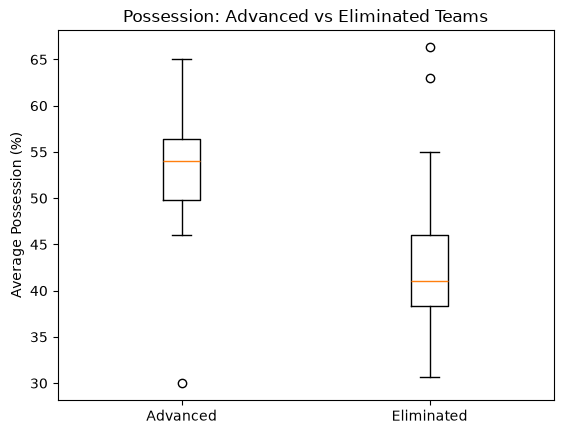

Advanced teams — mean possession: 52.59%
95% CI: (48.40%, 56.78%)

Eliminated teams — mean possession: 43.50%
95% CI: (38.05%, 48.95%)
t-statistic = 2.818
p-value = 0.00874

Result: Reject H0 — there IS a statistically significant difference
in average possession between Advanced and Eliminated teams.


In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/matches.csv")
print(df.shape)
df.head()

print(df.columns.tolist())
print(df["round"].unique())
print(df[["home_possession", "away_possession"]].isna().sum())

# Reshape home rows
home = df[["round", "gameweek", "date", "home_team", "away_team", "home_possession"]].copy()
home.columns = ["round", "gameweek", "date", "team", "opponent", "possession"]

# Reshape away rows
away = df[["round", "gameweek", "date", "away_team", "home_team", "away_possession"]].copy()
away.columns = ["round", "gameweek", "date", "team", "opponent", "possession"]

# Combine into one long table: one row per team per match
team_matches = pd.concat([home, away], ignore_index=True)
print(team_matches.shape)
team_matches.head()


# Define the order of rounds from earliest to latest
round_order = {
    "Group stage": 0,
    "Round of 32": 1,
    "Round of 16": 2,
    "Quarter-finals": 3,
    "Semi-finals": 4,
    "Third-place match": 5,
    "Final": 5
}

team_matches["round_rank"] = team_matches["round"].map(round_order)

# For each team, find the highest round_rank they reached
furthest_round = team_matches.groupby("team")["round_rank"].max().reset_index()
furthest_round.columns = ["team", "furthest_round_rank"]

# Label: rank 0 = only played Group stage = Eliminated. rank > 0 = Advanced.
furthest_round["group_label"] = furthest_round["furthest_round_rank"].apply(
    lambda r: "Eliminated" if r == 0 else "Advanced"
)

print(furthest_round["group_label"].value_counts())
furthest_round.head()


# Average possession per team across all their matches
avg_possession = team_matches.groupby("team")["possession"].mean().reset_index()
avg_possession.columns = ["team", "avg_possession"]

# Merge with the Advanced/Eliminated label
team_possession = avg_possession.merge(furthest_round[["team", "group_label"]], on="team")

print(team_possession.shape)
team_possession.head()


import numpy as np

advanced = team_possession.loc[team_possession["group_label"] == "Advanced", "avg_possession"]
eliminated = team_possession.loc[team_possession["group_label"] == "Eliminated", "avg_possession"]

print("Population - Advanced teams:", len(advanced))
print("Population - Eliminated teams:", len(eliminated))

np.random.seed(42)
n = min(len(advanced), len(eliminated), 16)   # cap sample size, keep both groups equal
sample_advanced = advanced.sample(n=n, random_state=42)
sample_eliminated = eliminated.sample(n=n, random_state=42)

print(f"\nSampled Advanced: {len(sample_advanced)}")
print(f"Sampled Eliminated: {len(sample_eliminated)}")

print("Advanced teams (sample) — possession stats:")
print(sample_advanced.describe())

print("\nEliminated teams (sample) — possession stats:")
print(sample_eliminated.describe())

import matplotlib.pyplot as plt

plt.boxplot([sample_advanced, sample_eliminated], tick_labels=["Advanced", "Eliminated"])
plt.ylabel("Average Possession (%)")
plt.title("Possession: Advanced vs Eliminated Teams")
plt.savefig("../outputs/figures/arpan_possession_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


from scipy import stats

mean_adv = sample_advanced.mean()
sem_adv = stats.sem(sample_advanced)
ci_adv = stats.t.interval(confidence=0.95, df=len(sample_advanced)-1, loc=mean_adv, scale=sem_adv)

mean_elim = sample_eliminated.mean()
sem_elim = stats.sem(sample_eliminated)
ci_elim = stats.t.interval(confidence=0.95, df=len(sample_eliminated)-1, loc=mean_elim, scale=sem_elim)

print(f"Advanced teams — mean possession: {mean_adv:.2f}%")
print(f"95% CI: ({ci_adv[0]:.2f}%, {ci_adv[1]:.2f}%)")

print(f"\nEliminated teams — mean possession: {mean_elim:.2f}%")
print(f"95% CI: ({ci_elim[0]:.2f}%, {ci_elim[1]:.2f}%)")


# H0: mean possession (Advanced) = mean possession (Eliminated)
# H1: mean possession (Advanced) ≠ mean possession (Eliminated)

t_stat, p_value = stats.ttest_ind(sample_advanced, sample_eliminated, equal_var=False)  # Welch's t-test

print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 — there IS a statistically significant difference")
    print("in average possession between Advanced and Eliminated teams.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant difference")
    print("in average possession between Advanced and Eliminated teams.")